## Metrics:
*AUROC*: It is the probability that a randomly chosen ID sample will have a higher "confidence score" than a randomly chosen OOD sample.

*FPR95*: If I want to save 95% of my real data, how much "garbage" is going to get into my system?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

/opt/anaconda3/envs/timedrl/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def add_entropy_to_results(results):
    probs = results['probs']
    
    # Calculate Entropy: -sum(p * log(p))
    # axis=1 performs the sum across the classes for each sample
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    
    results['entropy'] = entropy
    
    # For AUROC functions that expect Higher = ID:
    # Use negative entropy (because we want ID to be the "higher" score)
    results['neg_entropy'] = -entropy
    
    return results

In [3]:
def add_energy_to_results(results, T=1.0):
    logits = torch.from_numpy(results['logits'])
    # Energy = -T * log(sum(exp(logit/T)))
    energy = -T * torch.logsumexp(logits / T, dim=1).numpy()
    results['energy'] = energy
    return results

In [19]:
def calculate_metrics(id_scores, ood_scores):
    """Calculates AUROC and FPR95 for a pair of score arrays."""
    # Ensure higher scores = In-Distribution for AUROC
    all_scores = np.concatenate([id_scores, ood_scores])
    thresholds = np.sort(np.unique(all_scores))[::-1]
    
    n_id, n_ood = len(id_scores), len(ood_scores)
    tpr_list, fpr_list = [], []

    for t in thresholds:
        tpr_list.append(np.sum(id_scores >= t) / n_id)
        fpr_list.append(np.sum(ood_scores >= t) / n_ood)

    auroc = np.trapz(tpr_list, fpr_list)
    
    threshold_95tpr = np.percentile(id_scores, 5)
    fpr95 = (np.sum(ood_scores >= threshold_95tpr) / n_ood) * 100

    threshold_90tpr = np.percentile(id_scores, 10)
    fpr90 = (np.sum(ood_scores >= threshold_90tpr) / n_ood) * 100
    
    return auroc, fpr95, fpr90

In [23]:
def run_ood_evaluation_workflow(dataset_names, score_types=None):
    """
    Standardized workflow to evaluate multiple OOD detection methods across multiple datasets.
    """
    if score_types is None:
        score_types = ['max_conf', 'max_logit', 'neg_entropy', 'neg_energy', 'odin_score', 'mahal_distance']
    
    master_results = []

    for data_name in dataset_names:
        print(f"--- Processing Dataset: {data_name} ---")
        
        # 1. Load Data using your specific naming convention
        # Note: We split the suffix to insert 'id' or 'ood' correctly
        id_path = f"../analysis_results/{data_name}_n3_h2_id_v2.npz"
        ood_path = f"../analysis_results/{data_name}_n3_h2_ood_v2.npz"
        
        try:
            id_data = dict(np.load(id_path))
            ood_data = dict(np.load(ood_path))
        except FileNotFoundError:
            print(f"Warning: Files not found for {data_name}. Skipping...")
            continue

        # 2. Preprocess / Calculate additional scores
        id_data = add_entropy_to_results(id_data)
        ood_data = add_entropy_to_results(ood_data)
        id_data = add_energy_to_results(id_data)
        ood_data = add_energy_to_results(ood_data)

        if 'logits' in id_data:
            id_data['max_logit'] = np.max(id_data['logits'], axis=1)
            ood_data['max_logit'] = np.max(ood_data['logits'], axis=1)
        
        # OOD metrics typically expect "Higher score = More likely to be ID"
        # Since Mahalanobis is a DISTANCE (Higher = OOD), we negate it for AUROC calculations.
        if 'mahal_distance' in id_data:
            id_data['neg_mahal'] = -id_data['mahal_distance']
            ood_data['neg_mahal'] = -ood_data['mahal_distance']
        
        if 'energy' in id_data:
            id_data['neg_energy'] = -id_data['energy']
            ood_data['neg_energy'] = -ood_data['energy']

        # 3. Calculate Metrics (AUROC, FPR95) for each method
        for score in score_types:
            # Map logical name to the actual key in the dictionary
            lookup_key = 'neg_mahal' if score == 'mahal_distance' else score
            
            if lookup_key not in id_data:
                continue

            auroc, fpr95, fpr90 = calculate_metrics(id_data[lookup_key], ood_data[lookup_key])
            
            master_results.append({
                'Dataset': data_name,
                'Method': score.replace('neg_', '').replace('_score', '').upper(),
                'AUROC': auroc,
                'FPR95': fpr95,
                'FPR90': fpr90
            })

    return pd.DataFrame(master_results)

In [24]:
def plot_comparison_report(df):
    # 1. Prepare data structures for Matplotlib
    datasets = df['Dataset'].unique()
    methods = df['Method'].unique()
    
    n_datasets = len(datasets)
    n_methods = len(methods)
    
    # Set the width of each bar and the positions on the X-axis
    width = 0.8 / n_methods  # Total width of 0.8 shared by all bars in a group
    x_indices = np.arange(n_datasets)
    
    # Define a color palette
    colors = plt.cm.tab10(np.linspace(0, 1, n_methods))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 2. Loop through methods to plot each bar set
    for i, method in enumerate(methods):
        method_data = df[df['Method'] == method]
        
        # Calculate offset for the current method's bars
        # This centers the group of bars over the tick mark
        offset = (i - (n_methods - 1) / 2) * width
        
        # Plot AUROC
        ax1.bar(x_indices + offset, method_data['AUROC'], width, 
                label=method, color=colors[i], edgecolor='black', alpha=0.8)
        
        # Plot FPR95
        ax2.bar(x_indices + offset, method_data['FPR95'], width, 
                label=method, color=colors[i], edgecolor='black', alpha=0.8)

    # 3. Formatting AUROC (Subplot 1)
    ax1.set_title("AUROC Comparison (Higher is Better)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("AUROC Score", fontsize=12)
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(datasets)
    ax1.set_ylim(0.0, 1.0)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)
    ax1.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')

    # 4. Formatting FPR95 (Subplot 2)
    ax2.set_title("FPR at 95% TPR (Lower is Better)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("FPR95 (%)", fontsize=12)
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(datasets)
    ax2.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [25]:
# Execute Workflow
datasets = ["WISDM", "HAR"]
report_df = run_ood_evaluation_workflow(datasets)

--- Processing Dataset: WISDM ---
--- Processing Dataset: HAR ---


In [27]:
print(report_df)

   Dataset          Method     AUROC      FPR95      FPR90
0    WISDM        MAX_CONF  0.813850  90.029326  66.862170
1    WISDM       MAX_LOGIT  0.740518  89.442815  79.765396
2    WISDM         ENTROPY  0.784507  89.736070  81.231672
3    WISDM          ENERGY  0.706242  92.082111  82.111437
4    WISDM            ODIN  0.687346  93.548387  86.803519
5    WISDM  MAHAL_DISTANCE  0.790310  70.381232  52.199413
6      HAR        MAX_CONF  0.624227  92.821535  83.748754
7      HAR       MAX_LOGIT  0.735088  90.827517  74.675972
8      HAR         ENTROPY  0.628406  92.622134  82.951147
9      HAR          ENERGY  0.736742  90.827517  74.975075
10     HAR            ODIN  0.708293  87.736790  74.975075
11     HAR  MAHAL_DISTANCE  0.552981  98.504487  94.416750


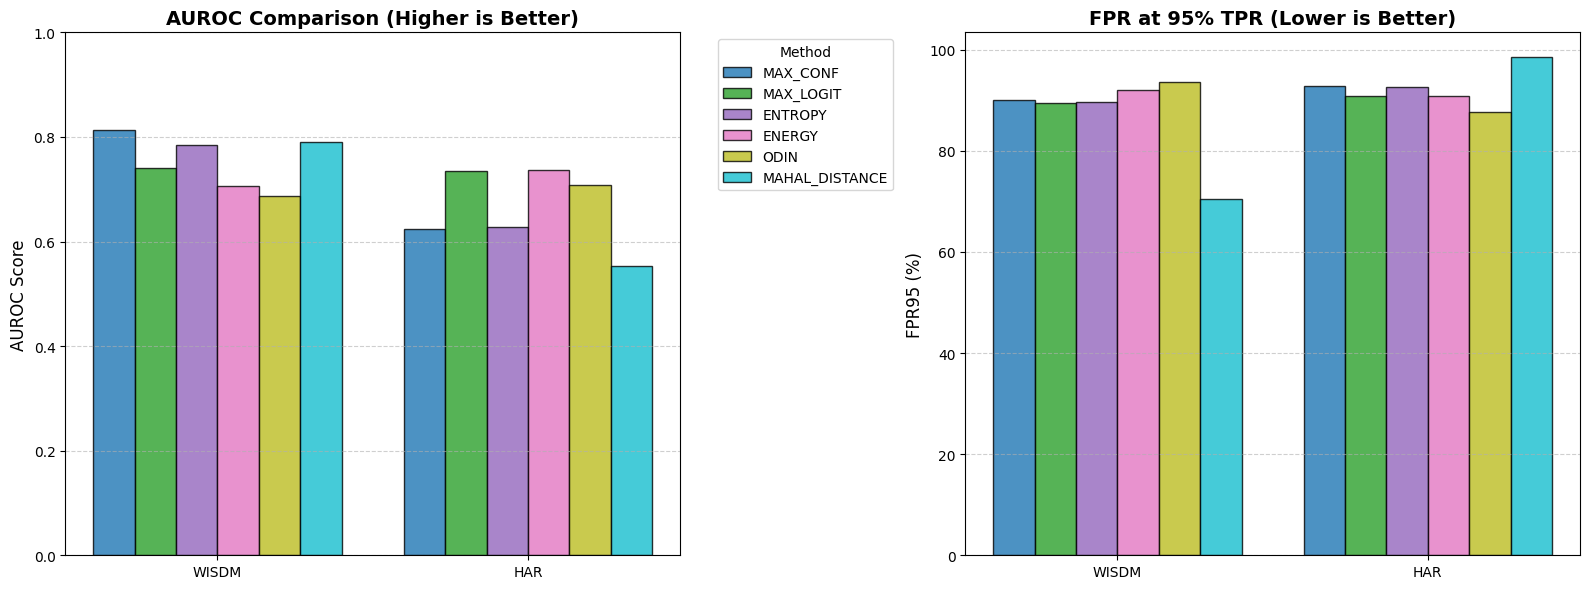

In [17]:
plot_comparison_report(report_df)